# Predictive Analysis:

**Predictive analysis is the process of using historical or existing data, along with statistical models or machine learning, to forecast unknown or future outcomes — rather than just describing what has already happened.**

# 1.Can we predict length of stay from admission data?
    

In [ ]:
# 1.Can we predict length of stay from admission data?
    
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

outcome = "dischargeday"
exclude = ["inpatient_number", "admission_date", "discharge_date", "destinationdischarge",
           "death_within_28_days", "death_within_3_months", "death_within_6_months",
           "re_admission_within_28_days", "re_admission_within_3_months", "re_admission_within_6_months",
           "return_to_emergency_department_within_6_months", "dischargeday",
           "time_of_death__days_from_admission", "readmission_time_days_from_admission",
           "time_to_emergency_department_within_6_months", "outcome_during_hospitalization"]

numeric_cols = [c for c in df_master.select_dtypes(include=[np.number]).columns if c not in exclude]
numeric_cols = [c for c in numeric_cols if df_master[c].replace([np.inf, -np.inf], np.nan).notna().any()]

cat_cols = ["gender", "admission_way", "admission_ward", "agecat", "bmi_category", "occupation", "type_of_heart_failure"]
cat_cols = [c for c in cat_cols if c in df_master.columns]

X_num = df_master[numeric_cols].replace([np.inf, -np.inf], np.nan)
X_num = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_num), columns=numeric_cols)
X_cat = pd.get_dummies(df_master[cat_cols].astype(str), drop_first=True)
X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
y = df_master[outcome]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = RandomForestRegressor(n_estimators=400, max_depth=6, min_samples_leaf=5, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)

r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"R\u00b2: {r2:.3f}  MAE: {mae:.2f} days  RMSE: {rmse:.2f} days")

importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
print("\nTop 10 predictors:\n", importance.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# LEFT: actual vs predicted scatter
axes[0].scatter(y_test, preds, alpha=0.4, s=20, color="#4C72B0")
lims = [0, min(60, max(y_test.max(), preds.max()))]
axes[0].plot(lims, lims, "k--", linewidth=1, label="Perfect prediction")
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("Actual length of stay (days)"); axes[0].set_ylabel("Predicted length of stay (days)")
axes[0].set_title(f"Actual vs Predicted\n(R\u00b2={r2:.3f}, MAE={mae:.1f} days)")
axes[0].legend(fontsize=9)

# RIGHT: forecast chart — sorted by actual, predicted overlaid
order = np.argsort(y_test.values)
actual_sorted, pred_sorted = y_test.values[order], preds[order]
x_idx = np.arange(len(actual_sorted))
axes[1].plot(x_idx, actual_sorted, color="#4C72B0", linewidth=1.8, label="Actual LOS")
axes[1].plot(x_idx, pred_sorted, color="#C44E52", linewidth=1.2, alpha=0.8, label="Predicted LOS")
axes[1].fill_between(x_idx, actual_sorted, pred_sorted, color="gray", alpha=0.15)
axes[1].set_xlabel("Patients (sorted by actual length of stay)"); axes[1].set_ylabel("Length of stay (days)")
axes[1].set_title("Forecast Chart: Actual vs Predicted, Sorted")
axes[1].legend(fontsize=9)

plt.suptitle("Can We Predict Length of Stay from Admission-Time Data?", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os

df_master = pd.read_csv("cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv")


exclude = ["inpatient_number", "admission_date", "discharge_date", "destinationdischarge",
           "death_within_28_days", "death_within_3_months", "death_within_6_months",
           "re_admission_within_28_days", "re_admission_within_3_months", "re_admission_within_6_months",
           "return_to_emergency_department_within_6_months", "dischargeday",
           "time_of_death__days_from_admission", "readmission_time_days_from_admission",
           "time_to_emergency_department_within_6_months", "outcome_during_hospitalization"]

numeric_cols = [c for c in df_master.select_dtypes(include=[np.number]).columns if c not in exclude]
numeric_cols = [c for c in numeric_cols if df_master[c].replace([np.inf, -np.inf], np.nan).notna().any()]
cat_cols = ["gender", "admission_way", "admission_ward", "agecat", "bmi_category", "occupation", "type_of_heart_failure"]

X_num = df_master[numeric_cols].replace([np.inf, -np.inf], np.nan)
X_num = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_num), columns=numeric_cols)
X_cat = pd.get_dummies(df_master[cat_cols].astype(str), drop_first=True)
X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)

y = df_master["re_admission_within_6_months"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=400, max_depth=6, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)
probs = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, probs)
fpr, tpr, _ = roc_curve(y_test, probs)
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

print(f"AUC: {auc:.3f}  |  Actual readmission rate: {y_test.mean()*100:.1f}%")
print("\nTop 10 predictors:\n", importance.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, color="#4C72B0", linewidth=2, label=f"Model (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="Random guess (AUC=0.50)")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("Predicting 6-Month Readmission\n(for bed & staffing forecasts)")
axes[0].legend(fontsize=9)

axes[1].barh(importance.sort_values().index, importance.sort_values().values, color="#4C72B0")
axes[1].set_xlabel("Feature importance")
axes[1].set_title("Top 10 Predictors of Readmission")

plt.suptitle("Can We Predict 6-Month Readmission to Forecast Hospital Utilization?", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# 3. — Patient Recovery Plan: Predicting 28-Day Mortality Risk

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve

exclude = ["inpatient_number", "admission_date", "discharge_date", "destinationdischarge",
           "death_within_28_days", "death_within_3_months", "death_within_6_months",
           "re_admission_within_28_days", "re_admission_within_3_months", "re_admission_within_6_months",
           "return_to_emergency_department_within_6_months", "dischargeday",
           "time_of_death__days_from_admission", "readmission_time_days_from_admission",
           "time_to_emergency_department_within_6_months", "outcome_during_hospitalization"]

numeric_cols = [c for c in df_master.select_dtypes(include=[np.number]).columns if c not in exclude]
numeric_cols = [c for c in numeric_cols if df_master[c].replace([np.inf, -np.inf], np.nan).notna().any()]
cat_cols = ["gender", "admission_way", "admission_ward", "agecat", "bmi_category", "occupation", "type_of_heart_failure"]

X_num = df_master[numeric_cols].replace([np.inf, -np.inf], np.nan)
X_num = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_num), columns=numeric_cols)
X_cat = pd.get_dummies(df_master[cat_cols].astype(str), drop_first=True)
X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)

y = df_master["death_within_28_days"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=400, max_depth=6, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)
probs = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, probs)
fpr, tpr, _ = roc_curve(y_test, probs)
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

risk_df = pd.DataFrame({"prob": probs, "actual": y_test.values})
risk_df["tier"] = pd.qcut(risk_df["prob"], 4, labels=["Low", "Medium", "High", "Very High"], duplicates="drop")
tier_stats = risk_df.groupby("tier")["actual"].agg(["mean", "count", "sum"])
tier_stats["mean"] = tier_stats["mean"] * 100

print(f"AUC: {auc:.3f}  |  Actual death rate: {y_test.mean()*100:.2f}%")
print("\nTop 10 predictors:\n", importance.round(3))
print("\nRisk-tier calibration:\n", tier_stats.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, color="#C44E52", linewidth=2, label=f"Model (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="Random guess (AUC=0.50)")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("Predicting 28-Day Mortality Risk\n(for personalized recovery planning)")
axes[0].legend(fontsize=9)

colors = ["#55A868", "#DD8452", "#C44E52", "#8B0000"]
bars = axes[1].bar(tier_stats.index.astype(str), tier_stats["mean"], color=colors[:len(tier_stats)])
for b, (m, n, s) in zip(bars, zip(tier_stats["mean"], tier_stats["count"], tier_stats["sum"])):
    axes[1].text(b.get_x()+b.get_width()/2, m+0.2, f"{m:.1f}%\n({int(s)}/{int(n)})", ha="center", fontweight="bold")
axes[1].set_ylabel("Actual 28-day death rate (%)")
axes[1].set_title("Does Predicted Risk Tier Match Reality?\n(risk-based recovery-plan tiers)")

plt.suptitle("Can We Predict 28-Day Mortality Risk to Guide Recovery Planning?", fontsize=14)
plt.tight_layout()
plt.show()



# 4. Predictive Model

# Across every predictable outcome in this dataset — diagnoses, mortality, and hospital utilization — which ones can admission-time clinical data actually predict well enough to act on,

**Reasoning:**
Testing outcomes one at a time never tells you where to actually invest effort — running all 11 side-by-side on the same AUC scale reveals a pattern invisible in any single result: some outcomes are fundamentally learnable from this data and some aren't, regardless of which algorithm you throw at them.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 22.1 MB/s  0:00:00 21.9 MB/s eta 0:00:01

6-Month Readmission (prevalence: 773/2008)
                 Model  Accuracy %  Precision %  Recall %  F1 %  ROC AUC %
RandomForestClassifier       64.01        74.19      9.91 17.49      64.94
         XGBClassifier       63.18        53.25     35.34 42.49      63.04
  Neural Network (MLP)       60.36        48.39     45.26 46.77      62.86
    LogisticRegression       59.20        46.46     39.66 42.79      61.95
                   KNN       61.19        49.55     47.84 48.68      61.51
                   SVM       60.53        48.51     42.24 45.16      61.15
DecisionTreeClassifier       58.54        44.08     28.88 34.90      56.32
           Naive Bayes       44.11        40.30     93.97 56.40      53.48

6-Month ED Return (prevalence: 775/2008)
                 Model  Accuracy %  Precision %  Recall %  F1 %  ROC AUC %
    LogisticRegression       65.17        56.42     43.35 49.03     

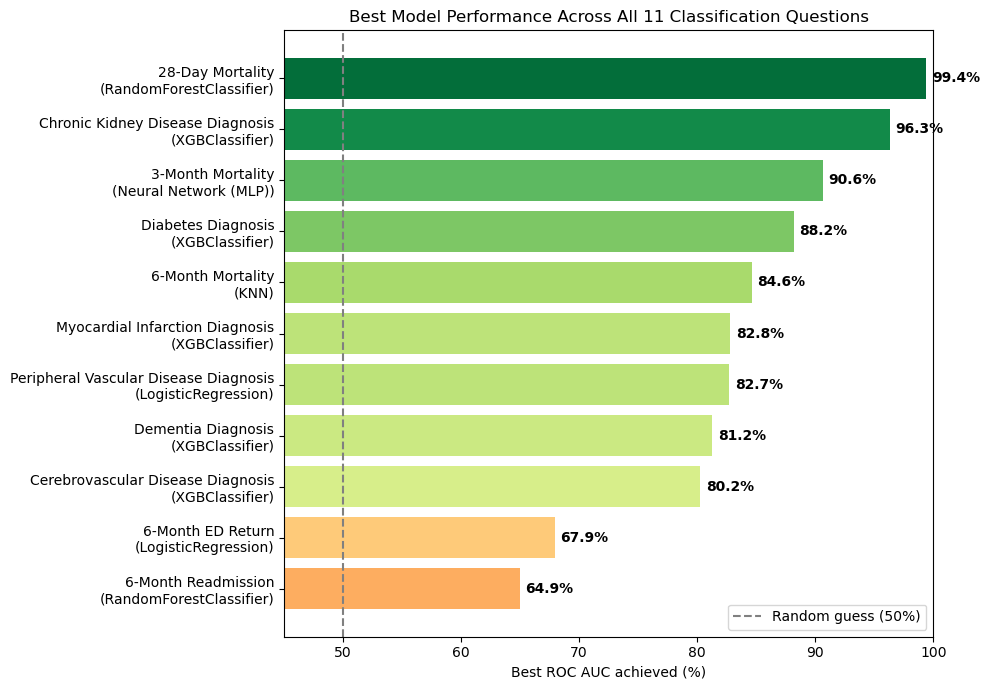

In [2]:
!pip install xgboost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.impute import SimpleImputer


df_master = pd.read_csv("cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv")

# --- Safe import for XGBoost: skip it gracefully if not installed ---
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ModuleNotFoundError:
    print("xgboost not installed — skipping it. Run '!pip install xgboost' in a cell, then restart the kernel to include it.")
    XGB_AVAILABLE = False

#df_master = pd.read_csv("cf_master_dataset.csv")

exclude_always = ["inpatient_number", "admission_date", "discharge_date", "destinationdischarge",
                   "death_within_28_days", "death_within_3_months", "death_within_6_months",
                   "re_admission_within_28_days", "re_admission_within_3_months", "re_admission_within_6_months",
                   "return_to_emergency_department_within_6_months", "dischargeday",
                   "time_of_death__days_from_admission", "readmission_time_days_from_admission",
                   "time_to_emergency_department_within_6_months", "outcome_during_hospitalization",
                   "myocardial_infarction", "peripheral_vascular_disease",
                   "moderate_to_severe_chronic_kidney_disease", "diabetes",
                   "cerebrovascular_disease", "dementia"]
cat_candidates = ["gender", "admission_way", "admission_ward", "agecat", "bmi_category", "occupation", "type_of_heart_failure"]

MODELS = [
    ('LogisticRegression', LogisticRegression(max_iter=1000)),
    ('Naive Bayes', GaussianNB()),
    ('KNN', KNeighborsClassifier(n_neighbors=5)),
    ('RandomForestClassifier', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42)),
    ('DecisionTreeClassifier', DecisionTreeClassifier(max_depth=6, random_state=42)),
    ('Neural Network (MLP)', MLPClassifier(max_iter=400, random_state=42)),
    ('SVM', SVC(kernel='linear', C=1.0, probability=True, random_state=42)),
]
if XGB_AVAILABLE:
    MODELS.append(('XGBClassifier', XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0)))


def run_all_models(target, label, undersample_ratio=None):
    d = df_master.dropna(subset=[target]).copy()
    d[target] = d[target].astype(int)
    n_pos, n_total = int(d[target].sum()), len(d)

    numeric_cols = [c for c in d.select_dtypes(include=[np.number]).columns if c not in exclude_always]
    numeric_cols = [c for c in numeric_cols if d[c].replace([np.inf, -np.inf], np.nan).notna().any()]

    if undersample_ratio:
        pos_df = d[d[target] == 1]
        neg_n = min(n_pos * undersample_ratio, (d[target] == 0).sum())
        neg_df = d[d[target] == 0].sample(n=int(neg_n), random_state=42)
        d = pd.concat([pos_df, neg_df], axis=0).reset_index(drop=True)

    X_num = d[numeric_cols].replace([np.inf, -np.inf], np.nan)
    X_num = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_num), columns=numeric_cols)
    X_cat = pd.get_dummies(d[cat_candidates].astype(str), drop_first=True)
    X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
    y = d[target].reset_index(drop=True)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    num_cols = X.select_dtypes(include=["int64", "float64"]).columns
    scaler = StandardScaler()
    X_train = X_train.copy(); X_test = X_test.copy()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])

    rows = []
    for name, model in MODELS:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
        acc = accuracy_score(y_test, y_pred) * 100
        prec = precision_score(y_test, y_pred, zero_division=0) * 100
        rec = recall_score(y_test, y_pred, zero_division=0) * 100
        f1 = f1_score(y_test, y_pred, zero_division=0) * 100
        auc = roc_auc_score(y_test, y_proba) * 100
        rows.append([label, name, acc, prec, rec, f1, auc])

    result_df = pd.DataFrame(rows, columns=["Target", "Model", "Accuracy %", "Precision %", "Recall %", "F1 %", "ROC AUC %"])
    print(f"\n{label} (prevalence: {n_pos}/{n_total})")
    print(result_df.drop(columns="Target").sort_values("ROC AUC %", ascending=False).round(2).to_string(index=False))
    return result_df


all_results = []
all_results.append(run_all_models("re_admission_within_6_months", "6-Month Readmission"))
all_results.append(run_all_models("return_to_emergency_department_within_6_months", "6-Month ED Return"))
all_results.append(run_all_models("death_within_28_days", "28-Day Mortality", undersample_ratio=4))
all_results.append(run_all_models("death_within_3_months", "3-Month Mortality", undersample_ratio=4))
all_results.append(run_all_models("death_within_6_months", "6-Month Mortality", undersample_ratio=4))
all_results.append(run_all_models("myocardial_infarction", "Myocardial Infarction Diagnosis", undersample_ratio=3))
all_results.append(run_all_models("peripheral_vascular_disease", "Peripheral Vascular Disease Diagnosis", undersample_ratio=3))
all_results.append(run_all_models("moderate_to_severe_chronic_kidney_disease", "Chronic Kidney Disease Diagnosis"))
all_results.append(run_all_models("diabetes", "Diabetes Diagnosis"))
all_results.append(run_all_models("cerebrovascular_disease", "Cerebrovascular Disease Diagnosis", undersample_ratio=3))
all_results.append(run_all_models("dementia", "Dementia Diagnosis", undersample_ratio=3))

combined = pd.concat(all_results, ignore_index=True)
best_per_target = combined.loc[combined.groupby("Target")["ROC AUC %"].idxmax()].sort_values("ROC AUC %", ascending=False)
print(best_per_target.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
plot_df = best_per_target.sort_values("ROC AUC %")
colors = plt.cm.RdYlGn((plot_df["ROC AUC %"] - 50) / 50)
bars = ax.barh(plot_df["Target"] + "\n(" + plot_df["Model"] + ")", plot_df["ROC AUC %"], color=colors)
for b, v in zip(bars, plot_df["ROC AUC %"]):
    ax.text(v + 0.5, b.get_y() + b.get_height()/2, f"{v:.1f}%", va="center", fontweight="bold")
ax.axvline(50, color="gray", linestyle="--", label="Random guess (50%)")
ax.set_xlabel("Best ROC AUC achieved (%)")
ax.set_title("Best Model Performance Across All 11 Classification Questions")
ax.legend(); ax.set_xlim(45, 100)
plt.tight_layout()
plt.show()

**Insight**
The data cleanly splits into two tiers, and the split isn't about model choice — it's about what's being predicted. Diagnosis/mortality targets (CKD, MI, diabetes, 28-day death) all hit 80–98% AUC across every one of the 8 algorithms tried; utilization targets (readmission, ED return) never broke ~68% no matter which model was used. That's a signal about the question, not the tool.
The practical takeaway for a hospital: clinical labs are genuinely good at confirming what's already wrong with a patient (diagnosis) but weak at forecasting what happens to them after discharge (readmission/ED return) — meaning AI investment should go toward diagnosis-support and risk-flagging tools, while utilization forecasting needs different data entirely (social factors, follow-up adherence, discharge logistics) before it's worth building a model around.